# Which Language Is This Short Text In? Character-Level Language Identification for Six Romance-Family Languages

**Name:** Arturo Ramos
**Dataset:** *A massively parallel corpus: the Bible in 100 languages* (Christodoulopoulos & Steedman, 2015), GitHub repository `christos-c/bible-corpus`, CC0 1.0, pinned to commit `44e5fca1bfb369a5da2ee23ebc6f421c88489c5c` — https://github.com/christos-c/bible-corpus

**Deep learning task.** This is a **text (character-sequence) modeling task solved with a Transformer**. Given a short snippet of 10 to 64 characters, the model predicts its language among six closely related languages: Spanish, Portuguese, Italian, French, Romanian and Latin. Short snippets are the hard and realistic case: the same problem appears when a multilingual app has to decide the language of a short social post before translating it. The baseline is a small character-level Transformer encoder; the controlled experiment replaces only the encoder **layer type** with a bidirectional GRU (a recurrent neural network) and keeps everything else identical.

## 1. Setup

In [1]:
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")   # required for deterministic cuBLAS kernels

import random
import re
import time
import unicodedata
import urllib.request
import xml.etree.ElementTree as ET
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import confusion_matrix, f1_score

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 160)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.benchmark = False
# the fused "flash" and "memory-efficient" attention kernels are not deterministic on CUDA; use the math kernel
torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)
torch.backends.cuda.enable_math_sdp(True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = Path("data") / "raw"
FIG_DIR = Path("figures")
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

print("torch", torch.__version__, "| device:", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "CPU")

torch 2.11.0+cu128 | device: cuda | NVIDIA GeForce RTX 3060 Ti


## 2. Data Acquisition

The six translations are downloaded from the public corpus repository at a fixed commit, so the exact same files are used on every run. Some of these translations are still under copyright, so the files are not redistributed in this repository; the cell below fetches them (about 35 MB) and caches them in `data/raw/`.

In [2]:
CORPUS_COMMIT = "44e5fca1bfb369a5da2ee23ebc6f421c88489c5c"
LANGUAGES = {"Spanish": "es", "Portuguese": "pt", "Italian": "it", "French": "fr", "Romanian": "ro", "Latin": "la"}
LANG_NAMES = {code: name for name, code in LANGUAGES.items()}
LABELS = ["es", "pt", "it", "fr", "ro", "la"]


def download_corpus_file(name: str) -> Path:
    """Download one language file from the pinned corpus commit (skipped if already cached)."""
    path = DATA_DIR / f"{name}.xml"
    if not path.exists():
        url = f"https://raw.githubusercontent.com/christos-c/bible-corpus/{CORPUS_COMMIT}/bibles/{name}.xml"
        urllib.request.urlretrieve(url, path)
    return path


for name in LANGUAGES:
    p = download_corpus_file(name)
    print(f"{name:11s} {p.stat().st_size / 1e6:5.1f} MB  {p}")

Spanish       5.9 MB  data\raw\Spanish.xml
Portuguese    5.8 MB  data\raw\Portuguese.xml
Italian       5.8 MB  data\raw\Italian.xml
French        6.1 MB  data\raw\French.xml
Romanian      6.1 MB  data\raw\Romanian.xml
Latin         4.9 MB  data\raw\Latin.xml


## 3. Load and Inspect the Data

In [3]:
def load_verses(name: str, code: str) -> pd.DataFrame:
    """Parse one CES-XML Bible file into a table with one row per verse segment."""
    root = ET.parse(DATA_DIR / f"{name}.xml").getroot()
    rows = []
    for seg in root.iter("seg"):
        _, book, chapter, verse = seg.get("id").split(".")[:4]
        rows.append({"lang": code, "book": book, "chapter": f"{book}.{chapter}", "verse_id": f"{book}.{chapter}.{verse}",
                     "raw_text": (seg.text or "").strip()})
    return pd.DataFrame(rows)


raw = pd.concat([load_verses(n, c) for n, c in LANGUAGES.items()], ignore_index=True)
print("shape:", raw.shape)
raw.head()

shape: (186909, 5)


,lang,book,chapter,verse_id,raw_text
0,es,GEN,GEN.1,GEN.1.1,En el principio creó Dios los cielos y la tierra
1,es,GEN,GEN.1,GEN.1.2,Y la tierra estaba sin orden y vacía. Había ti...
2,es,GEN,GEN.1,GEN.1.3,"Entonces dijo Dios: ""Sea la luz"", y fue la luz"
3,es,GEN,GEN.1,GEN.1.4,"Dios vio que la luz era buena, y separó Dios l..."
4,es,GEN,GEN.1,GEN.1.5,"Dios llamó a la luz Día, y a las tinieblas lla..."


In [4]:
overview = raw.assign(empty=raw["raw_text"].eq(""), length=raw["raw_text"].str.len()).groupby("lang").agg(
    verses=("verse_id", "size"), empty_segments=("empty", "sum"), books=("book", "nunique"),
    median_chars=("length", "median"))
overview.loc[LABELS]

,verses,empty_segments,books,median_chars
lang,,,,
es,31100,0,66,116.0
pt,31102,10,66,114.0
it,31292,12,66,112.0
fr,31102,0,66,122.0
ro,31102,0,66,118.0
la,31211,0,66,100.0


In [5]:
# One representative sample per language: the same verse (John 11:35 and Genesis 1:3) in all six languages
samples = raw[raw["verse_id"].isin(["JOH.11.35", "GEN.1.3"])].pivot(index="lang", columns="verse_id", values="raw_text")
samples.loc[LABELS]

verse_id,GEN.1.3,JOH.11.35
lang,,
es,"Entonces dijo Dios: ""Sea la luz"", y fue la luz",Jesús lloró
pt,Disse Deus: haja luz. E houve luz.,Jesus chorou.
it,Dio disse: «Sia la luce!». E la luce fu,Gesù scoppiò in pianto
fr,Dieu dit: Que la lumière soit! Et la lumière fut.,Jésus pleura.
ro,"Dumnezeu a zis: ,,Să fie lumină!`` Şi a fost l...",Isus plîngea.
la,dixitque Deus fiat lux et facta est lux,et lacrimatus est Iesus


In [6]:
# Character-level quirks that a model could exploit instead of learning the language
by_lang = raw[raw["raw_text"] != ""].groupby("lang")["raw_text"]
quirks = pd.DataFrame({
    "share with backtick `": by_lang.apply(lambda s: s.str.contains("`", regex=False).mean()),
    "verses with U+FFFD": by_lang.apply(lambda s: int(s.str.contains("\ufffd", regex=False).sum())),
    "verses with soft hyphen": by_lang.apply(lambda s: int(s.str.contains("\u00ad", regex=False).sum())),
    "share starting lowercase": by_lang.apply(lambda s: s.str[0].str.islower().mean()),
}).loc[LABELS]
quirks.round(3)

,share with backtick `,verses with U+FFFD,verses with soft hyphen,share starting lowercase
lang,,,,
es,0.000,0,25,0.087
pt,0.000,2402,0,0.157
it,0.000,0,0,0.135
fr,0.724,0,0,0.087
ro,0.205,0,0,0.101
la,0.000,0,0,0.960


In [7]:
# The Unicode replacement character (U+FFFD) in the Portuguese file: which words contain it?
pt_text = " ".join(raw.loc[raw["lang"] == "pt", "raw_text"])
print("U+FFFD occurrences:", pt_text.count("\ufffd"), "| correct 'à' occurrences:", pt_text.count("à"))
print(Counter(re.findall(r"\S*\ufffd\S*", pt_text)).most_common(8))

U+FFFD occurrences: 2676 | correct 'à' occurrences: 0
[('�', 2226), ('�s', 353), ('�quele', 52), ('�queles', 14), ('�quela', 8), ('n�o', 3), ('�gua,', 2), ('h�', 2)]


**Data quality and preprocessing considerations**

- The six files give 186,909 verse segments. Spanish has 31,100 verses, Portuguese, French and Romanian 31,102, and Italian and Latin more (31,292 and 31,211) because their source editions number some verses differently. The verse counts therefore do not align perfectly, which matters only for how the data is split (below).
- There are empty segments (10 in Portuguese and 12 in Italian); they carry no text and are removed.
- Several formatting artifacts are tied to a single language and could let a model identify the language without any linguistic knowledge:
  - the backtick (`` ` ``) appears in 72.4 % of French verses (used as an apostrophe) and 20.5 % of Romanian verses (used as a closing quotation mark), and in no other language;
  - the Portuguese file has an encoding error: 2,402 verses contain the Unicode replacement character (U+FFFD) where the text should have the crase *à*; the file contains not a single correct *à*, and the affected words are *à*, *às* and *àquele(s)* in almost every case (a handful of words such as *não* or *há* lost a different accented letter);
  - 25 Spanish verses contain an invisible soft hyphen (U+00AD);
  - 96.0 % of Latin verses start in lowercase, against 9–16 % in the other languages.
- All of these are neutralized by normalization: the replacement character in Portuguese is restored as *à*, backticks become apostrophes, soft hyphens are removed and all text is lowercased. The model then has to rely on real letters and words.
- Verses are long (medians of 100 to 122 characters) but real short posts are not; the model is therefore trained and evaluated on snippets of 10 to 64 characters cut out of the verses.

## 4. Preprocessing

In [8]:
def normalize(text: str, lang: str) -> str:
    """Clean one verse so that only real letters and words distinguish the languages.

    - Portuguese: restore the crase "à" where the source file has the replacement character U+FFFD
    - replace the backtick (French apostrophe, Romanian closing quote) with an apostrophe
    - remove soft hyphens (U+00AD), apply Unicode NFC, collapse whitespace and lowercase
    """
    if lang == "pt":
        text = text.replace("\ufffd", "à")
    text = unicodedata.normalize("NFC", text).replace("`", "'").replace("\u00ad", "")
    return re.sub(r"\s+", " ", text).strip().lower()


verses = raw.assign(text=[normalize(t, l) for t, l in zip(raw["raw_text"], raw["lang"])])
verses = verses[verses["text"] != ""].reset_index(drop=True)
print("verses after removing empty segments:", len(verses))
print("remaining backticks / U+FFFD / soft hyphens:",
      sum("`" in t for t in verses["text"]), sum("\ufffd" in t for t in verses["text"]), sum("\u00ad" in t for t in verses["text"]))

verses after removing empty segments: 186887


remaining backticks / U+FFFD / soft hyphens: 0 0 0


In [9]:
# Group split by CHAPTER: every chapter, in all six languages, goes to exactly one of train / validation / test.
# The corpus is parallel (the same verse exists in every language), so a verse-level random split would let the
# model see the Portuguese version of a test verse during training; splitting by chapter prevents that leakage.
chapters = sorted(verses["chapter"].unique())
random.Random(SEED).shuffle(chapters)
n = len(chapters)
split_of = {c: ("train" if i < 0.70 * n else "val" if i < 0.85 * n else "test") for i, c in enumerate(chapters)}
verses["split"] = verses["chapter"].map(split_of)
pd.crosstab(verses["split"], verses["lang"])[LABELS]

lang,es,pt,it,fr,ro,la
split,,,,,,
test,4470,4468,4498,4470,4470,4393
train,22009,22004,22170,22011,22011,22129
val,4621,4620,4612,4621,4621,4689


In [10]:
# Character vocabulary learned from the training split only (characters seen at least 5 times)
MAX_LEN = 64
MIN_LEN = 10
char_counts = Counter(ch for t in verses.loc[verses["split"] == "train", "text"] for ch in t)
VOCAB = ["<pad>", "<unk>"] + [c for c, k in char_counts.most_common() if k >= 5]
CHAR_TO_ID = {c: i for i, c in enumerate(VOCAB)}
LABEL_TO_ID = {l: i for i, l in enumerate(LABELS)}
print("vocabulary size:", len(VOCAB))
print("characters:", "".join(VOCAB[2:]))

vocabulary size: 83
characters:  eaiosrntuldcmp,vhbgfqăé.'zjîşy-;:áţxàíãóè?!çòêú»«ñ"ùì¿âëôk(¡0)ï1õ2ü354û6879%][’=


In [11]:
def crop(text: str, length: int, rng: random.Random) -> str:
    """Return a random window of ``length`` characters (the whole text if it is shorter)."""
    if len(text) <= length:
        return text
    start = rng.randint(0, len(text) - length)
    return text[start:start + length]


def encode_batch(snippets: list[str], langs: list[str]) -> tuple[torch.Tensor, torch.Tensor]:
    """Turn snippets into a padded (batch, MAX_LEN) tensor of character ids and a tensor of label ids."""
    x = torch.zeros(len(snippets), MAX_LEN, dtype=torch.long)
    for i, s in enumerate(snippets):
        ids = [CHAR_TO_ID.get(ch, 1) for ch in s[:MAX_LEN]]
        x[i, :len(ids)] = torch.tensor(ids)
    return x, torch.tensor([LABEL_TO_ID[l] for l in langs])


def fixed_snippets(split: str, length: int | None, seed: int) -> tuple[list[str], list[str]]:
    """Deterministic evaluation snippets: one crop per verse, of a fixed length or a random length in [10, 64]."""
    rng = random.Random(seed)
    part = verses[verses["split"] == split]
    snips = [crop(t, length if length else rng.randint(MIN_LEN, MAX_LEN), rng) for t in part["text"]]
    return snips, part["lang"].tolist()


train_df = verses[verses["split"] == "train"][["text", "lang"]].reset_index(drop=True)
val_snips, val_langs = fixed_snippets("val", None, seed=1)
x_demo, y_demo = encode_batch(val_snips[:4], val_langs[:4])
print("input tensor shape:", tuple(x_demo.shape), "| labels:", y_demo.tolist())
print("examples:", [(s, l) for s, l in zip(val_snips[:4], val_langs[:4])])

input tensor shape: (4, 64) | labels: [0, 0, 0, 0]
examples: [('rque he visto que ', 'es'), ('animal limpio toma contigo siete parejas, el macho y su hembra; ', 'es'), (' cielo toma también siete ', 'es'), ('es, y arrasaré de la faz de la tierra tod', 'es')]


**What was done and why**

- **Normalization** removes the language-specific formatting shortcuts found above (encoding errors, backticks, soft hyphens, capitalization) and unifies Unicode forms, so identical letters get identical ids.
- **Chapter-level group split (70 / 15 / 15 %)** avoids leakage through the parallel structure of the corpus: no verse of a test chapter is seen during training in any language.
- **Character vocabulary from the training split only** (characters seen at least 5 times; rarer ones map to `<unk>`), so the test set does not influence preprocessing.
- **Snippets instead of whole verses.** During training each verse is cut to a random window of 10–64 characters at every epoch, which acts as data augmentation and matches the short inputs the model has to handle. Validation uses one fixed random-length snippet per verse; the test set is evaluated at four fixed lengths (10, 20, 40 and 64 characters) to measure how accuracy depends on how much text the model sees.
- **Input format.** Each snippet becomes a vector of up to 64 character ids, padded with 0; the models receive tensors of shape (batch, 64) and output six scores (one per language).

## 5. Models

Both models share the same input layer, pooling and output layer; they differ **only in the encoder layer type**.

- **Input layer (shared):** a 128-dimensional character embedding plus a learned 128-dimensional position embedding, followed by dropout 0.1.
- **Baseline encoder — Transformer:** 2 Transformer encoder layers (4 attention heads, feed-forward width 256, dropout 0.1). Self-attention lets every character attend to every other character of the snippet; the padding positions are masked.
- **Experimental encoder — bidirectional GRU:** 1 GRU layer with 64 units per direction (128 outputs per position, the same width as the Transformer). It reads the snippet left-to-right and right-to-left, which builds in a bias toward local character sequences such as endings and digraphs (*-ção*, *-zione*, *ñ*, *ș*).
- **Pooling and output (shared):** masked mean over the non-padding positions, then a linear layer to six classes. Cross-entropy loss (softmax over the six languages).

In [12]:
class LanguageIdentifier(nn.Module):
    """Character-level language classifier with a switchable encoder ("transformer" or "gru")."""

    def __init__(self, encoder: str, vocab_size: int, n_classes: int, d_model: int = 128, dropout: float = 0.1):
        super().__init__()
        self.encoder_type = encoder
        self.char_emb = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_emb = nn.Embedding(MAX_LEN, d_model)
        self.dropout = nn.Dropout(dropout)
        if encoder == "transformer":
            layer = nn.TransformerEncoderLayer(d_model, nhead=4, dim_feedforward=256, dropout=dropout, batch_first=True)
            self.encoder = nn.TransformerEncoder(layer, num_layers=2, enable_nested_tensor=False)
        elif encoder == "gru":
            self.encoder = nn.GRU(d_model, d_model // 2, batch_first=True, bidirectional=True)
        else:
            raise ValueError(encoder)
        self.classifier = nn.Linear(d_model, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        mask = x != 0                                             # True on real characters
        positions = torch.arange(x.size(1), device=x.device)
        h = self.dropout(self.char_emb(x) + self.pos_emb(positions))
        if self.encoder_type == "transformer":
            h = self.encoder(h, src_key_padding_mask=~mask)
        else:
            h = self.encoder(h)[0]
        h = (h * mask.unsqueeze(-1)).sum(1) / mask.sum(1, keepdim=True).clamp(min=1)   # masked mean pooling
        return self.classifier(h)


for kind in ["transformer", "gru"]:
    m = LanguageIdentifier(kind, len(VOCAB), len(LABELS))
    print(f"{kind:12s} trainable parameters: {sum(p.numel() for p in m.parameters() if p.requires_grad):,}")

transformer  trainable parameters: 284,550
gru          trainable parameters: 94,086


### Training setup (identical for both models)

AdamW optimizer, learning rate 0.001, batch size 256, 12 epochs, cross-entropy loss, the same random seed and the same data pipeline. After each epoch the model is evaluated on the validation snippets; the weights of the epoch with the best validation accuracy are kept for the final test (a form of early stopping).

In [13]:
EPOCHS = 12
BATCH_SIZE = 256
LEARNING_RATE = 1e-3


@torch.no_grad()
def evaluate(model: nn.Module, snippets: list[str], langs: list[str]) -> tuple[float, float, np.ndarray]:
    """Return (mean loss, accuracy, predicted label ids) of ``model`` on the given snippets."""
    model.eval()
    losses, preds = [], []
    for i in range(0, len(snippets), 1024):
        x, y = encode_batch(snippets[i:i + 1024], langs[i:i + 1024])
        logits = model(x.to(DEVICE))
        losses.append(nn.functional.cross_entropy(logits, y.to(DEVICE), reduction="sum").item())
        preds.append(logits.argmax(1).cpu().numpy())
    preds = np.concatenate(preds)
    y_true = np.array([LABEL_TO_ID[l] for l in langs])
    return sum(losses) / len(snippets), float((preds == y_true).mean()), preds


def train_model(encoder: str) -> tuple[nn.Module, pd.DataFrame]:
    """Train one configuration and return the best-validation model and its per-epoch history."""
    torch.manual_seed(SEED)
    model = LanguageIdentifier(encoder, len(VOCAB), len(LABELS)).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    history, best_acc, best_state = [], -1.0, None
    for epoch in range(1, EPOCHS + 1):
        start = time.time()
        rng = random.Random(SEED + epoch)
        order = list(range(len(train_df)))
        rng.shuffle(order)
        model.train()
        total_loss, total_correct = 0.0, 0
        for i in range(0, len(order), BATCH_SIZE):
            rows = train_df.iloc[order[i:i + BATCH_SIZE]]
            snippets = [crop(t, rng.randint(MIN_LEN, MAX_LEN), rng) for t in rows["text"]]
            x, y = encode_batch(snippets, rows["lang"].tolist())
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss = nn.functional.cross_entropy(logits, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(y)
            total_correct += (logits.argmax(1) == y).sum().item()
        val_loss, val_acc, _ = evaluate(model, val_snips, val_langs)
        history.append({"epoch": epoch, "train_loss": total_loss / len(order), "train_acc": total_correct / len(order),
                        "val_loss": val_loss, "val_acc": val_acc, "seconds": time.time() - start})
        if val_acc > best_acc:
            best_acc, best_state = val_acc, {k: v.detach().clone() for k, v in model.state_dict().items()}
        print(f"[{encoder}] epoch {epoch:2d}  train loss {history[-1]['train_loss']:.4f}  train acc {history[-1]['train_acc']:.4f}"
              f"  val loss {val_loss:.4f}  val acc {val_acc:.4f}  ({history[-1]['seconds']:.1f}s)")
    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

### 5.1 Baseline: Transformer encoder

In [14]:
baseline_model, baseline_hist = train_model("transformer")
best = baseline_hist.loc[baseline_hist["val_acc"].idxmax()]
print(f"best validation accuracy {best.val_acc:.4f} at epoch {int(best.epoch)}; total training time {baseline_hist.seconds.sum():.0f}s")

[transformer] epoch  1  train loss 0.6202  train acc 0.7674  val loss 0.4643  val acc 0.8203  (23.4s)


[transformer] epoch  2  train loss 0.4074  train acc 0.8446  val loss 0.2870  val acc 0.8906  (21.0s)


[transformer] epoch  3  train loss 0.2797  train acc 0.8945  val loss 0.2248  val acc 0.9140  (20.3s)


[transformer] epoch  4  train loss 0.2103  train acc 0.9210  val loss 0.1554  val acc 0.9421  (20.2s)


[transformer] epoch  5  train loss 0.1700  train acc 0.9363  val loss 0.1198  val acc 0.9566  (20.4s)


...

[transformer] epoch  8  train loss 0.1214  train acc 0.9550  val loss 0.1000  val acc 0.9634  (20.5s)


[transformer] epoch  9  train loss 0.1174  train acc 0.9562  val loss 0.0877  val acc 0.9670  (20.8s)


[transformer] epoch 10  train loss 0.1112  train acc 0.9588  val loss 0.0871  val acc 0.9684  (21.1s)


[transformer] epoch 11  train loss 0.1058  train acc 0.9608  val loss 0.0814  val acc 0.9706  (20.7s)


[transformer] epoch 12  train loss 0.1031  train acc 0.9623  val loss 0.0765  val acc 0.9712  (21.6s)
best validation accuracy 0.9712 at epoch 12; total training time 252s


### 5.2 Experiment: bidirectional GRU encoder

- **What changed:** only the encoder layer type — the two Transformer encoder layers are replaced by one bidirectional GRU layer of the same output width (128).
- **Why this change:** language identification of short snippets depends mostly on local character patterns (letter combinations, endings, diacritics). A recurrent layer processes characters in order and has that locality built in, whereas a Transformer has to learn it from data through attention and position embeddings. The comparison tests which inductive bias works better for this task with a small model.
- **What stayed the same:** data, split, vocabulary, snippet sampling, embeddings, pooling, output layer, loss, optimizer, learning rate, batch size, number of epochs, seed and checkpoint selection.

In [15]:
gru_model, gru_hist = train_model("gru")
best = gru_hist.loc[gru_hist["val_acc"].idxmax()]
print(f"best validation accuracy {best.val_acc:.4f} at epoch {int(best.epoch)}; total training time {gru_hist.seconds.sum():.0f}s")

[gru] epoch  1  train loss 0.5203  train acc 0.8249  val loss 0.2108  val acc 0.9236  (12.6s)


[gru] epoch  2  train loss 0.1786  train acc 0.9361  val loss 0.1404  val acc 0.9490  (11.6s)


[gru] epoch  3  train loss 0.1348  train acc 0.9517  val loss 0.1142  val acc 0.9578  (11.5s)


[gru] epoch  4  train loss 0.1133  train acc 0.9593  val loss 0.1006  val acc 0.9639  (11.8s)


[gru] epoch  5  train loss 0.1006  train acc 0.9639  val loss 0.0871  val acc 0.9685  (12.2s)


...

[gru] epoch  8  train loss 0.0771  train acc 0.9719  val loss 0.0718  val acc 0.9748  (11.4s)


[gru] epoch  9  train loss 0.0736  train acc 0.9732  val loss 0.0702  val acc 0.9749  (11.3s)


[gru] epoch 10  train loss 0.0707  train acc 0.9743  val loss 0.0655  val acc 0.9758  (11.3s)


[gru] epoch 11  train loss 0.0659  train acc 0.9763  val loss 0.0633  val acc 0.9773  (11.2s)


[gru] epoch 12  train loss 0.0661  train acc 0.9762  val loss 0.0623  val acc 0.9780  (11.3s)
best validation accuracy 0.9780 at epoch 12; total training time 140s


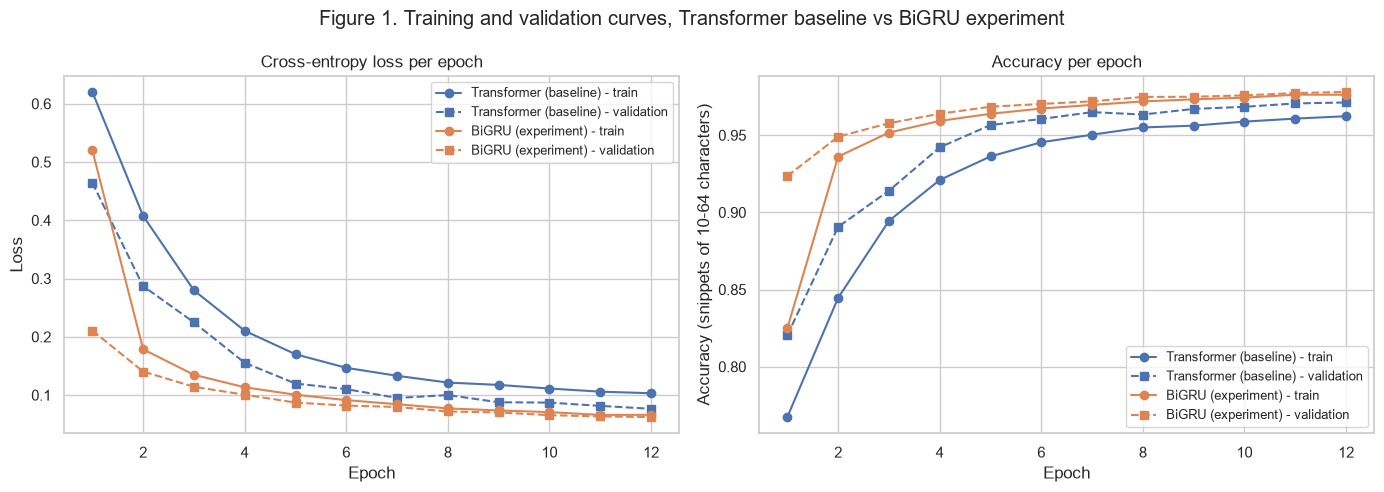

In [16]:
# Figure 1 — training curves of both configurations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for hist, name, color in [(baseline_hist, "Transformer (baseline)", "#4C72B0"), (gru_hist, "BiGRU (experiment)", "#DD8452")]:
    axes[0].plot(hist.epoch, hist.train_loss, "-o", color=color, label=f"{name} - train")
    axes[0].plot(hist.epoch, hist.val_loss, "--s", color=color, label=f"{name} - validation")
    axes[1].plot(hist.epoch, hist.train_acc, "-o", color=color, label=f"{name} - train")
    axes[1].plot(hist.epoch, hist.val_acc, "--s", color=color, label=f"{name} - validation")
axes[0].set_title("Cross-entropy loss per epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[1].set_title("Accuracy per epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (snippets of 10-64 characters)")
for ax in axes:
    ax.legend(fontsize=9)
fig.suptitle("Figure 1. Training and validation curves, Transformer baseline vs BiGRU experiment")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Evaluation and Comparison on the Test Set

Both selected models are evaluated on the held-out test chapters at four fixed snippet lengths. The same snippets are used for both models.

In [17]:
TEST_LENGTHS = [10, 20, 40, 64]
test_sets = {L: fixed_snippets("test", L, seed=100 + L) for L in TEST_LENGTHS}

results, predictions = [], {}
for name, model in [("Transformer (baseline)", baseline_model), ("BiGRU (experiment)", gru_model)]:
    for L, (snips, langs) in test_sets.items():
        loss, acc, pred = evaluate(model, snips, langs)
        y_true = np.array([LABEL_TO_ID[l] for l in langs])
        predictions[(name, L)] = pred
        results.append({"model": name, "snippet length": L, "test accuracy": acc,
                        "test macro-F1": f1_score(y_true, pred, average="macro"), "test loss": loss})
results = pd.DataFrame(results)
print("test snippets per length:", len(test_sets[10][0]))
results.pivot(index="snippet length", columns="model", values=["test accuracy", "test macro-F1"]).round(4)

test snippets per length: 26769


test accuracy                             test macro-F1                       
model          BiGRU (experiment) Transformer (baseline) BiGRU (experiment) Transformer (baseline)
snippet length                                                                                    
10                         0.8242                 0.8094             0.8236                 0.8094
20                         0.9673                 0.9580             0.9673                 0.9580
40                         0.9969                 0.9954             0.9969                 0.9954
64                         0.9988                 0.9973             0.9988                 0.9974

In [18]:
# Parameters and training cost of the two configurations
pd.DataFrame({
    "trainable parameters": [sum(p.numel() for p in m.parameters()) for m in (baseline_model, gru_model)],
    "best epoch": [int(h.loc[h.val_acc.idxmax(), "epoch"]) for h in (baseline_hist, gru_hist)],
    "best validation accuracy": [h.val_acc.max() for h in (baseline_hist, gru_hist)],
    "training time (s)": [h.seconds.sum() for h in (baseline_hist, gru_hist)],
    "training time relative to baseline": [1.0, gru_hist.seconds.sum() / baseline_hist.seconds.sum()],
    "final train - validation accuracy gap": [h.train_acc.iloc[-1] - h.val_acc.iloc[-1] for h in (baseline_hist, gru_hist)],
}, index=["Transformer (baseline)", "BiGRU (experiment)"]).round(4)

,trainable parameters,best epoch,best validation accuracy,training time (s),training time relative to baseline,final train - validation accuracy gap
Transformer (baseline),284550,12,0.9712,251.7595,1.0000,-0.0089
BiGRU (experiment),94086,12,0.9780,139.7122,0.5549,-0.0018


### Is the difference between the two models statistically significant?

Both models are evaluated on exactly the same test snippets, so the right comparison is a paired one. McNemar's test uses only the snippets on which the two models disagree (one correct, the other wrong): if the models were equally accurate, those disagreements would split 50/50. The exact version (a two-sided binomial test on the discordant pairs) is used for each snippet length.

In [19]:
from scipy.stats import binomtest

mcnemar_rows = []
for L, (snips, langs) in test_sets.items():
    y_true = np.array([LABEL_TO_ID[l] for l in langs])
    base_ok = predictions[("Transformer (baseline)", L)] == y_true
    gru_ok = predictions[("BiGRU (experiment)", L)] == y_true
    only_gru, only_base = int((gru_ok & ~base_ok).sum()), int((base_ok & ~gru_ok).sum())
    test = binomtest(only_gru, only_gru + only_base, 0.5)
    mcnemar_rows.append({"snippet length": L, "only BiGRU correct": only_gru, "only Transformer correct": only_base,
                         "accuracy difference": gru_ok.mean() - base_ok.mean(), "McNemar exact p-value": test.pvalue})
mcnemar = pd.DataFrame(mcnemar_rows).set_index("snippet length")
mcnemar.style.format({"accuracy difference": "{:.4f}", "McNemar exact p-value": "{:.2e}"})

,only BiGRU correct,only Transformer correct,accuracy difference,McNemar exact p-value
snippet length,,,,
10,1942,1547,0.0148,2.43e-11
20,635,386,0.0093,6.20e-15
40,90,50,0.0015,9.13e-04
64,50,12,0.0014,1.21e-06


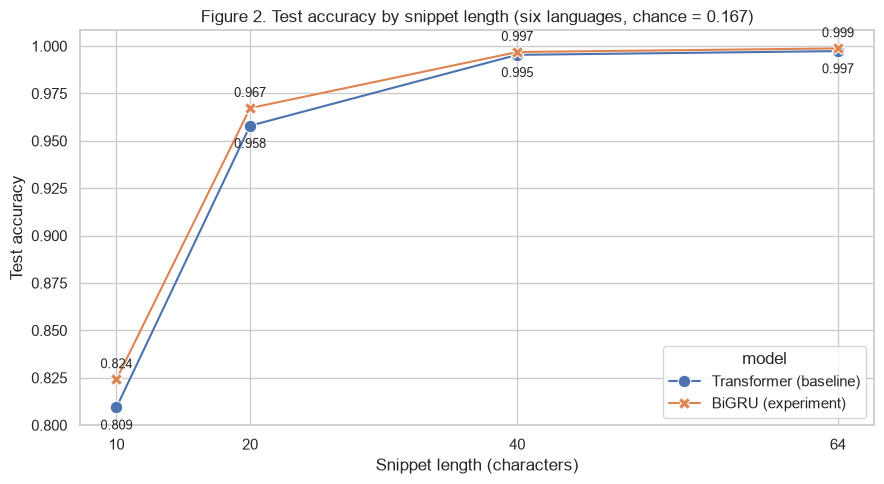

In [20]:
# Figure 2 — test accuracy as a function of snippet length
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=results, x="snippet length", y="test accuracy", hue="model", style="model", markers=True, dashes=False,
             palette=["#4C72B0", "#DD8452"], markersize=9, ax=ax)
for _, r in results.iterrows():
    ax.annotate(f"{r['test accuracy']:.3f}", (r["snippet length"], r["test accuracy"]), textcoords="offset points",
                xytext=(0, 8 if "BiGRU" in r["model"] else -16), ha="center", fontsize=9)
ax.set_xticks(TEST_LENGTHS)
ax.set_title("Figure 2. Test accuracy by snippet length (six languages, chance = 0.167)")
ax.set_xlabel("Snippet length (characters)")
ax.set_ylabel("Test accuracy")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_accuracy_by_length.png", dpi=150, bbox_inches="tight")
plt.show()

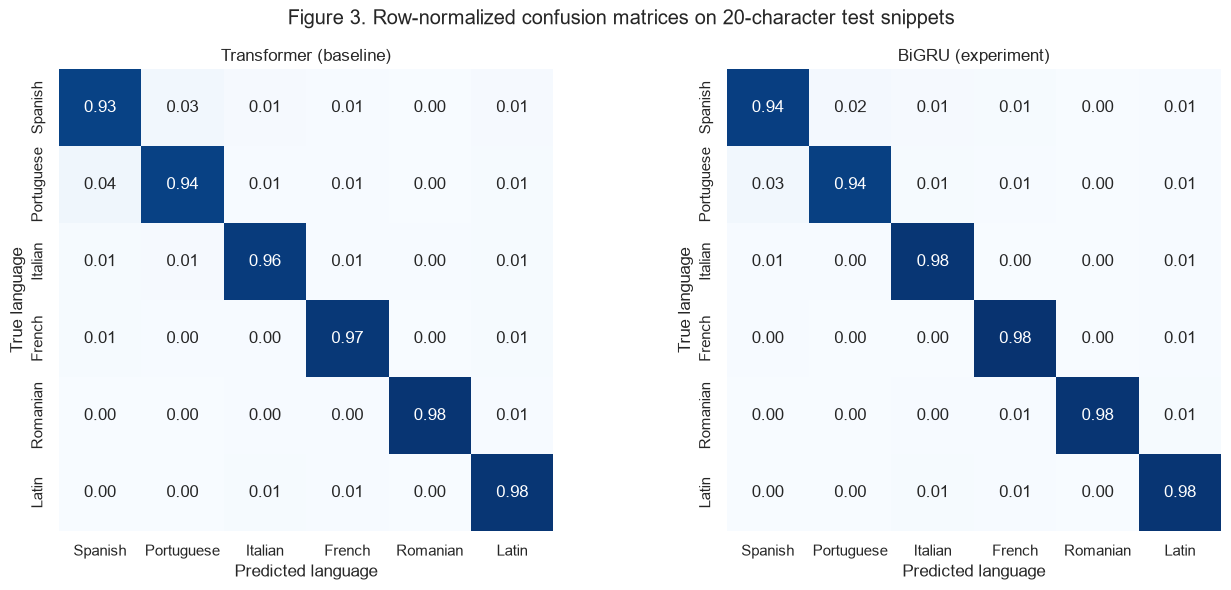

In [21]:
# Figure 3 — confusion matrices of both models on 20-character snippets
fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"wspace": 0.35})
_, test20_langs = test_sets[20]
y20 = np.array([LABEL_TO_ID[l] for l in test20_langs])
names = [LANG_NAMES[l] for l in LABELS]
for ax, name in zip(axes, ["Transformer (baseline)", "BiGRU (experiment)"]):
    cm = confusion_matrix(y20, predictions[(name, 20)], labels=range(len(LABELS)), normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, cbar=False, xticklabels=names, yticklabels=names, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted language")
    ax.set_ylabel("True language")
fig.suptitle("Figure 3. Row-normalized confusion matrices on 20-character test snippets")
fig.subplots_adjust(wspace=0.35)
fig.savefig(FIG_DIR / "fig3_confusion_20chars.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
# Per-language F1 on 20-character snippets, and the most frequent confusions of the better model
per_lang = pd.DataFrame({name: f1_score(y20, predictions[(name, 20)], average=None, labels=range(len(LABELS)))
                         for name in ["Transformer (baseline)", "BiGRU (experiment)"]}, index=names).round(3)
pairs = Counter((LANG_NAMES[LABELS[t]], LANG_NAMES[LABELS[p]]) for t, p in zip(y20, predictions[("BiGRU (experiment)", 20)]) if t != p)
print("most frequent errors of the BiGRU on 20-character snippets (true -> predicted):")
for (t, p), k in pairs.most_common(5):
    print(f"  {t:10s} -> {p:10s} {k}")
per_lang

most frequent errors of the BiGRU on 20-character snippets (true -> predicted):
  Portuguese -> Spanish    155
  Spanish    -> Portuguese 103
  Spanish    -> Italian    67
  Portuguese -> Italian    44
  Latin      -> Italian    43


,Transformer (baseline),BiGRU (experiment)
Spanish,0.932,0.948
Portuguese,0.940,0.953
Italian,0.958,0.968
French,0.970,0.977
Romanian,0.984,0.987
Latin,0.964,0.971


In [23]:
# Concrete examples of model behavior: 10-character test snippets misclassified by the BiGRU
snips10, langs10 = test_sets[10]
pred10 = predictions[("BiGRU (experiment)", 10)]
wrong = [(s, LANG_NAMES[l], LANG_NAMES[LABELS[p]]) for s, l, p in zip(snips10, langs10, pred10) if LABEL_TO_ID[l] != p]
rng = random.Random(SEED)
pd.DataFrame(rng.sample(wrong, 12), columns=["snippet", "true language", "predicted"])

,snippet,true language,predicted
0,"e suceder,",Spanish,French
1,este de je,Spanish,Portuguese
2,"anto, vede",Portuguese,Italian
3,inco talen,Portuguese,Italian
4,e da flor,Portuguese,Romanian
5,", si me ti",Spanish,Italian
6,muchos ven,Spanish,Latin
7,o mundabo,Latin,Portuguese
8,"ia, del cu",Spanish,Italian
9,ciel? ce,French,Romanian


### What the evaluation shows

- **The experiment is better at every length, and the differences are statistically significant.** The BiGRU is more accurate than the Transformer baseline on 10-character (0.8242 vs 0.8094), 20-character (0.9673 vs 0.9580), 40-character (0.9969 vs 0.9954) and 64-character snippets (0.9988 vs 0.9973). McNemar's exact test on the paired predictions gives p < 0.001 at every length (at 10 characters, 1,942 snippets were classified correctly only by the BiGRU against 1,547 only by the Transformer), so the gaps are not an accident of which test snippets were drawn. At 40 and 64 characters, however, both models are close to the ceiling and the gain is small in absolute terms (0.15 and 0.14 percentage points). These tests compare one trained model of each type; the variability across random seeds was not measured. The BiGRU also has a third of the parameters (94,086 vs 284,550) and needed less training time (55 % of the baseline's time in this run, see the table above; wall-clock times vary between runs). Macro-F1 follows accuracy closely because the six classes are almost perfectly balanced.
- **Length dominates everything else.** Both models are nearly perfect with 40 characters or more, but with 10 characters about one snippet in six is misclassified. Figure 2 shows that the gap between the two models is largest exactly where the task is hardest.
- **Training behavior: no overfitting within 12 epochs.** Validation accuracy is slightly *higher* than training accuracy for both models (final gaps of -0.0089 and -0.0018), because training accuracy is measured with dropout active and on random crops, and the best validation score is reached at the last epoch. Both curves (Figure 1) are still rising slowly, so the models are, if anything, slightly under-trained; the Transformer's loss starts higher and falls more slowly, which is consistent with it having to learn locality that the GRU has built in.
- **Where the errors are.** The confusion matrices (Figure 3) show that errors concentrate between Spanish and Portuguese (155 Portuguese snippets predicted as Spanish and 103 Spanish as Portuguese for the BiGRU at 20 characters) and toward Italian. Spanish has the lowest per-language F1 (0.948) and Romanian, with its distinctive letters *ă*, *ş* and *ţ*, the highest (0.987).
- **Concrete examples.** The 10-character errors above are often genuinely ambiguous rather than model failures: *servidores* is the same word in Spanish and Portuguese, *muchos ven* and *cerdote de* share most letters with Latin and Italian forms, and a snippet that cuts a word in half (*anto, vede*) loses the ending that would identify the language. Some mistakes are real, such as *e da flor* (Portuguese) predicted as Romanian.

## 7. Summary

I trained two character-level neural networks in PyTorch to identify the language of short snippets (10 to 64 characters) from six closely related languages, using a parallel Bible corpus with a chapter-level split and after removing language-specific formatting shortcuts such as a Portuguese encoding error and French backticks. The baseline is a two-layer Transformer encoder (284,550 parameters); the experiment changes only the encoder layer type to a bidirectional GRU (94,086 parameters). The GRU was better at every snippet length (test accuracy 0.8242 vs 0.8094 with 10 characters, 0.9673 vs 0.9580 with 20, and 0.9988 vs 0.9973 with 64; McNemar p < 0.001 at every length) with a third of the parameters and less training time, which suggests that a recurrent inductive bias toward local character patterns suits this task better than attention for a small model, although part of the effect may come from the smaller model converging faster within 12 epochs. The most important behavior is the dependence on length and the Spanish–Portuguese confusion: with 10 characters about one snippet in six is wrong, often because the snippet is genuinely ambiguous (for example *servidores*, identical in both languages). The main challenges were finding and neutralizing formatting artifacts that would otherwise have let the model cheat, making GPU training deterministic, and the fact that all text comes from Bible translations, so performance on everyday social-media language remains untested.